# Assignment 2: Using `pandas`

## Submitting the assignment

1. When you are done, rename this Colab file to HW2 <username>,.ipynb eg "HW2 deb219.ipynb".
1. Then _**share**_ this work file with me (deb219@lehigh.edu) by clicking the big Share button in the upper right of this page.
1. And upload it to coursesite under HW1 for record keeping (File > Download > ipynb).

**I'll subtract points for not doing any these things.**

## Pre-requisites

You have seen
- Pandas functions and methods in the lecture files
- Asset-return calculations from the toy examples

## Learning goals:

- Learn about Compustat
- Explore Compustat data
- Apply application exercises in class to real data

## Time expectations

**Stop working after 90 minutes and ask me and your classmates about it in the Groupme chat if you aren't done.**

## High quality firm accounting data

Compustat contains accounting data for publicly traded firms through time. It is professional grade dataset that contains accounting data from SEC filings.

I've given you a subset of firms from 2020 with variables
- "gvkey", "lpermno", "lpermno" = different datasets use different identifiers for firms
- "fyear" = the fiscal year the remaining variable apply to
- "gsector" = gsector, an industry classification (see [the wiki article on GICS](https://en.wikipedia.org/wiki/Global_Industry_Classification_Standard))
- "state" = of headquarters
- "tic" = ticker
- various accounting statistics


In [ ]:
import pandas as pd
import numpy as np
import pandas_datareader as pdr  # to install: !pip install pandas_datareader
from datetime import datetime

# this file can be found here: https://github.com/LeDataSciFi/data/blob/main/Firm%20Year%20Datasets%20(Compustat)/firms2020.csv
# if you click on the file, then click "raw", you'll be at the url below,
# which contains the raw data. pandas can download/load it without saving it locally!
url = 'https://github.com/LeDataSciFi/data/raw/main/Firm%20Year%20Datasets%20(Compustat)/firms2020.csv'
firms_df = pd.read_csv(url).drop_duplicates('tic')

## Part 1 - create variables

To that dataframe, add these variables:
1. $log(assets)$
1. $leverage = (dlc+dltt)/at $
1. $cash\_a = che/at$
1. $capx\_a = capx/at$
1. $rd\_a = xrd/at$
1. $capx\_ratio = capx/(capx+xrd)$
1. The average cash in the firm's `gsector`. Hint: Look up `transform()`, and this might make sense: `firms_df['ind_mean_cash'] = firms_df.groupby('gsector')['cash_at'].transform('mean')`

TIP: You might get a "RuntimeWarning". You can just ignore this and proceed! Please note that  this does indicate a problem within the dataset which we would need to fix if this was a full-bore project.

HINT: My industry mean cash variable has 1,208 observations (count), and averages 0.25, with a min and max of 0.07 and 0.44.

In [ ]:
firms_df = (firms_df
            .assign(log_assets  = np.log(firms_df['at']),
                    leverage    = (firms_df['dlc']+firms_df['dltt'])/firms_df['at'],
                    cash_at     = firms_df['che']  / firms_df['at'],
                    capx_at     = firms_df['capx'] / firms_df['at'],
                    xrd_at      = firms_df['xrd']  / firms_df['at'],
                    capx_ratio  = firms_df['capx'] / (firms_df['capx']+firms_df['xrd']),
                   )
)

# we need to use leverage to create the last variable, but we can't refer to leverage
# inside the assign() that creates it, so we just do it after that assign(), either in
# second assign() call, or like this:
firms_df['ind_med_lev'] = firms_df.groupby('gsector')['leverage'].transform('median')


## Part 2: EDA

Let's implement some best practices for **the EDA dropdown and data cleaning dropdown.**  Specifically, let's:

- What is the unit of observation and the key(s) variables that uniquely identify observations? You can type `df[possible_key_var_or_vars].isunique` to check if it is.
- Are there duplicate rows? Duplicate keys?
-  `.describe()` the variables you just made. Learn the averages.
- Any weird values in that description report? Anything that draws your attention?

Optional:
- What's the shape of the dataset?
- Names and variable types of the dataset? (Focus on vars about the firm and time (sample info), descriptors of the firm (industry etc), our new vars, and a few underlying vars we used to make the new ones.)
- Literally print out chunks of the dataset and look at it. (But, after you do, please comment the print() statements out so your submission doesn't look so messy)
- Explore time and place (sample - when and where?)

In [ ]:
# work on part 2 here

# gvkey fyear is the key variables, and a firm-year is the unit of observation
assert firms_df[['GVKEY','fyear']].duplicated(keep=False).sum() == 0
# firms_df.columns

In [ ]:
vars_to_desc = ['at','log_assets','leverage','cash_at','capx_at','xrd_at','capx_ratio','ind_med_lev']
firms_df[vars_to_desc].describe().T.style.format("{:,.2f}") # the .T transposes the table to fit on screen

,count,mean,std,min,25%,50%,75%,max
at,"1,213.00","32,225.12","153,377.96",0.65,774.17,"3,235.42","14,397.42","2,819,627.00"
log_assets,"1,213.00",7.98,2.36,-0.43,6.65,8.08,9.57,14.85
leverage,"1,170.00",0.27,0.22,0.00,0.08,0.25,0.41,1.60
cash_at,"1,210.00",0.18,0.18,0.00,0.05,0.12,0.24,1.00
capx_at,931.00,0.03,0.03,0.00,0.01,0.02,0.04,0.29
xrd_at,591.00,0.07,0.15,0.00,0.01,0.03,0.09,2.09
capx_ratio,527.00,0.45,0.34,0.00,0.14,0.39,0.74,1.00
ind_med_lev,"1,208.00",0.25,0.11,0.07,0.20,0.24,0.34,0.44


## Part 3 - Portfolio returns

Let's apply the lecture code this week to plot real returns.

1. Plot the cumulative returns for each firm separately
1. Plot the 60 day rolling volatility for each stock

HINT: Plotting these in `seaborn` is so much easier, because `sns` likes plotting "tall" data. `import seaborn as sns`, then `sns.lineplot(...)`.

Optional:
- Plot the cumulative returns for the buy and hold portfolio of all three of these firms
- Choose your own adventure


In [ ]:
stocks = ['AAPL','MSFT','META'] # pick three tickers

In [ ]:
import pandas_datareader as pdr  # to install: !pip install pandas_datareader
from datetime import datetime
import yfinance as yf

start = datetime(2020, 2, 1)
end = datetime(2025, 9, 1)

# download stock prices
stock_prices         = yf.download(stocks, start , end)
stock_prices.index   = stock_prices.index.tz_localize(None)
stock_prices         = stock_prices.filter(like='Close')
stock_prices.columns = stock_prices.columns.get_level_values(1)

# refmt from wide to long
stock_prices = stock_prices.stack().swaplevel().sort_index().reset_index()
stock_prices.columns = ['Firm','Date','Close']

# add return var = pct_change() function compares to prior row
# EXCEPT: don't compare for first row of one firm with last row of prior firm!
# MAKE SURE YOU CREATE THE VARIABLES WITHIN EACH FIRM - use groupby
stock_prices['ret'] = stock_prices.groupby('Firm')['Close'].pct_change()
stock_prices


/tmp/ipython-input-3258418331.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices         = yf.download(stocks, start , end)
[*********************100%***********************]  3 of 3 completed


,Firm,Date,Close,ret
0,AAPL,2020-02-03,74.545486,NaN
1,AAPL,2020-02-04,77.006508,0.033014
2,AAPL,2020-02-05,77.634438,0.008154
3,AAPL,2020-02-06,78.542534,0.011697
4,AAPL,2020-02-07,77.474937,-0.013593
...,...,...,...,...
4201,MSFT,2025-08-25,504.260010,-0.005855
4202,MSFT,2025-08-26,502.040009,-0.004402
4203,MSFT,2025-08-27,506.739990,0.009362
4204,MSFT,2025-08-28,509.640015,0.005723


In [ ]:
print('Downloaded returns for', stock_prices['Firm'].nunique(),'firms')
print('---')
display(stock_prices.describe())

Downloaded returns for 3 firms
---


,Date,Close,ret
count,4206,4206.000000,4203.000000
mean,2022-11-14 01:33:27.988587776,270.623517,0.001106
min,2020-02-03 00:00:00,54.316936,-0.263901
25%,2021-06-23 00:00:00,170.393757,-0.009448
50%,2022-11-10 12:00:00,234.578087,0.001109
75%,2024-04-08 00:00:00,330.454620,0.012213
max,2025-08-29 00:00:00,790.000000,0.232824
std,NaN,137.751150,0.022884


[Text(0.5, 1.0, 'Growth of $1')]

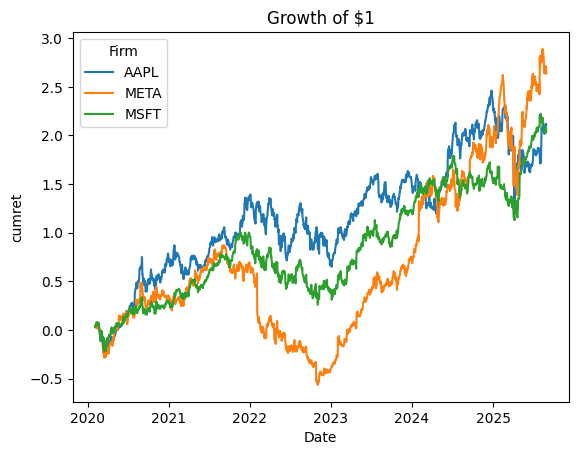

In [ ]:
# #1 - took the prof lecture file code in the 05 class, changed the df name to match, then added a line of code to plot

import seaborn as sns

# First, work here on getting the cum rets
stock_prices['cumret'] = \
(
    stock_prices
    .assign(ret=1+stock_prices['ret'])
    .groupby('Firm') # run the code with and without this line to see how important it is!
    ['ret']
    .cumprod()
    -1
)

sns.lineplot(data=stock_prices, x='Date', y='cumret', hue='Firm').set(title='Growth of $1')

[Text(0.5, 1.0, 'Rolling 60 trading day vol')]

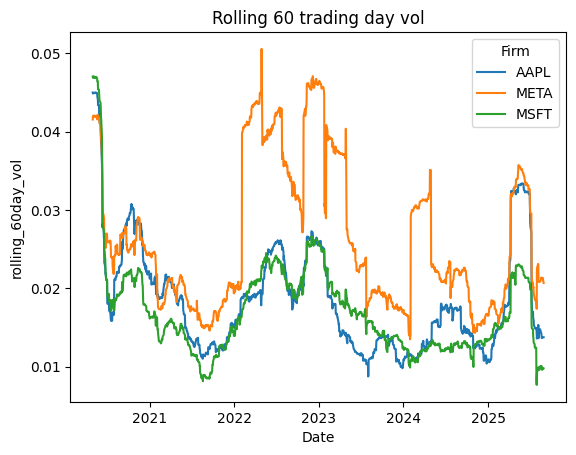

In [ ]:
# 2 - I took code from the same lecture and adjusted. this isn't a moving avg, but a moving vol

# First, work here on getting the cum rets
stock_prices['rolling_60day_vol'] = \
(
    stock_prices
    .groupby('Firm') # run the code with and without this line to see how important it is!
    .rolling(60)
    ['ret']
    .std()
    .reset_index(level=0, drop=True) # we need to drop the "date" index to add it back to the main dataset (which is a row number index)
)

sns.lineplot(data=stock_prices, x='Date', y='rolling_60day_vol', hue='Firm').set(title='Rolling 60 trading day vol')


**NOTE - rolling(60) looks up 60 rows in the data, not 60 days.**

Below, (not expected of anyone), I compute it to use 60 calendar days. It's very similar, unsuprisingly.


[Text(0.5, 1.0, 'Rolling 60 trading day vol')]

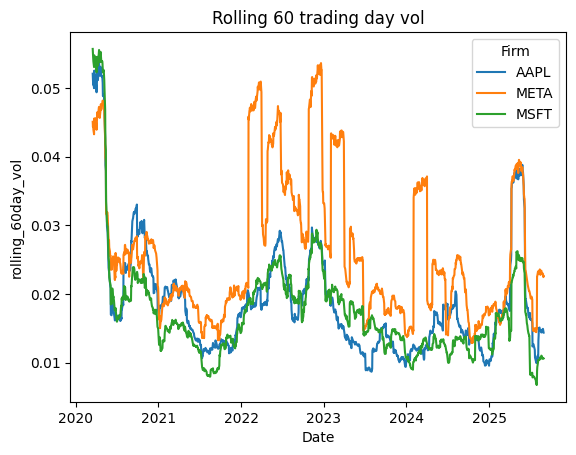

In [ ]:

# First, work here on getting the cum rets
stock_prices['rolling_60day_vol'] = \
(
    stock_prices
    .set_index(['Date']) # add this
    .groupby('Firm')
    .rolling('60D',30)   # change this to 60D
    ['ret']
    .std()               # change to std
    .reset_index(drop=True)
)

sns.lineplot(data=stock_prices, x='Date', y='rolling_60day_vol', hue='Firm').set(title='Rolling 60 trading day vol')


## Part 4

Make a series of 5+ (in total) plots to explore any of the 7 variables we created above in a series of plots. Choose your own adventure.
- For individual variables, you can try some of: kde, box, histograms. `.plot()` is sufficient.
- You can't do any time graphs sadly. All the data is 2020!
- Do at least one scatterplot of 2 variables.
- Try the seaborn `pairplot` function (just on our 7 variables)

Optional:
- Correlations (use a math function, not a plot). HINT: `.corr()`
- Upgrade: Gemini can make a very nice "heatmap" of correlations. I have them on the LDSF website too.
- How are the "industry mean cash" and "leverage" variables related? Why is this positive or negative, in terms of economic reasoning



In [ ]:
# work here

## Part 5

Ask Gemini to do a lot of EDA and graphs on those 7 variables, encourage it to use seaborn graphs and to try to use Skimpy and/or ydata-profiling. Ask it to include a "readme markdown" cell with data/variable descriptions and background.

When I did it, Gemini made a bunch of new cells of code. It wasn't error-free, but it was a great start.

You might need to experiment with your prompt to get a nice and thorough output.